# MATH-509: Lab 08

**Ben Miller**

[PLACEHOLDER_FOR_NOTEBOOK_LINK]


## Getting Started

Follow the instructions below to copy this notebook and to perform some initial setup.

1. Copy this notebook by selecting `File > Save a copy in Drive`.
2. A new window should open for the copied notebook. Move the new notebook to your course folder in Google Drive by selecting `File > Move` and then selecting the desired folder.
3. Update the name of the notebook by removing "Copy of" and replacing "Username" with your actual username.
4. Update the first cell in the notebook by replacing "Student Name" with your actual name.
5. Do not edit the line that says `PLACEHOLDER_FOR_NOTEBOOK_LINK`. This will be used by the [notebook renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool to insert a link to your Colab notebook.
6. Enable link sharing for your notebook.

## Double-Check Your Notebook

Please make sure that you are working in your own copy of the notebook before you proceed. Work completed in the template notebook will not be saved! Take a look at the URL for this notebook. If you see the string `1XB_eDi01p6Yf6poXktw1GKogRXvclwkx`, then you are in the template, NOT your own copy.

## Import Statements

Run the cell below to import the NumPy, Matplotlib, and math packages.  **No other packages are to be used in this assignment.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

Four arrays have been created to store the datasets that you will be working with in this lab. Running the cell below will import those arrays into your workspace. We will describe the imported arrays later in this notebook. The cell will also import some functions that will be used to test your code in Problem 7. Run that cell now.

In [2]:
%%capture
!git clone https://github.com/drbeane/MATH_509.git
from MATH_509.lab_08 import X1, y1, X2, y2
from MATH_509.lab_08 import unit_test_1, unit_test_2, unit_test_3

# Problem 1 - Simulating Stock Prices

A commonly used model for predicting stock prices assumes that yield rates for the stock over some period of time follow a normal distribution. As an example of this, let $R$ be a random variable representing the annual yield rate for a certain stock over the coruse of the next year. We will assume that:

$$R \sim N(\mu=0.1, \sigma^2 = 0.09) $$

Suppose that the current price of a share of the stock is 100. Let $S$ denote the price of a share of the stock at the end the year. Then $S$ and $R$ are related as follows:

$$S = 100 e^R$$

We will use Monte Carlo simulation to explore the distribution of the price of the stock.

## Part 1.A

Use the cell below to complete the following tasks.
1. Use NumPy to set a seed of 1.
2. Generate a sample of 10,000 observations of $R$.
3. Use the sample of $R$ values to generate a sample of $S$ values.
4. Calculate and print the following values, each rounded to 4 decimal places.
  * The mean of the sample of $S$.
  * The standard deviation of the sample of $S$.
  * The minimum of the sample of $S$.
  * The maximum of the sample of $S$.

In [3]:
np.random.seed(1)
R = np.random.normal(loc=0.1, scale=0.3, size=10_000)
S = 100 * np.exp(R)
print(round(S.mean(), 4))
print(round(S.std(ddof=1), 4))
print(round(S.min(), 4))
print(round(S.max(), 4))

115.9451
35.7195
36.901
369.8971


## Part 1.B

Replace the blank in the cell below with the name of the variable representing the sample of $S$ and then run the cell.

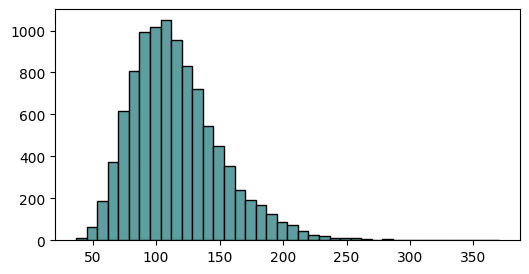

In [4]:
plt.figure(figsize=[6,3])
plt.hist(S, bins=40, color='cadetblue', edgecolor='k')
plt.show()

## Part 1.C

Use your sample to estimate the following probabilities. Then print each probability estimate.

* $P[S > 100]$

* $P[S > 150]$

* $P[S > 200]$

In [5]:
P1_S = np.mean(S > 100)
P2_S = np.mean(S > 150)
P3_S = np.mean(S > 200)

print(P1_S)
print(P2_S)
print(P3_S)

0.6372
0.1538
0.0252


# Problem 2 - Call Option Payout

A **call option** is a financial instrument that pays its holder if the price of a certain stock is higher than a preset threshold on a specified date. The threshold is called the **strike price** of the call. If the price of the stock is higher than the strike price on the expiration date for the call, then the call pays its owner the difference between the two prices. If the stock price is lower than the strike price, then the call pays nothing.

Suppose a call on the stock in Problem 1 has a strike price of 120 and expires one year from today. Then the payout of the stock will be:


$$\textrm{Payout} =
    \begin{cases}
        0 & \text{if } S~ < 120\\
        S - 120 & \text{otherwise }
    \end{cases}
$$



We will use simulation to explore the payout of this call.

## Part 2.A

Use the cell below to complete the following tasks.
1. Use `np.where()` to calculate the payout of the call for each observation of $S$ in the sample generated in Problem 1.
2. Calculate and print the mean and standard deviation of the sample of payouts, each rounded to 4 decimal places.

In [6]:
payout = np.where(S < 120, 0, S - 120)
payout_std = payout.std(ddof=1)
payout_mean = payout.mean()
print(round(payout_std, 4))
print(round(payout_mean, 4))

23.3122
12.1021


## Part 2.B

Use your sample of payouts to estimate the following probabilities. Then print each probability estimate.

* $P[\textrm{Payout} = 0]$

* $P[\textrm{Payout} < 20]$

* $P[\textrm{Payout} < 40]$

In [7]:
payout_0 = np.mean(payout == 0)
payout_under20 = np.mean(payout < 20)
payout_under40 = np.mean(payout < 40)

print(payout_0)
print(payout_under20)
print(payout_under40)

0.6057
0.7867
0.8914


# Problem 3 - Outage Times

Suppose that a factory has occasional outages of varying lengths. Let $T$ denote the length of time for an outage in minutes. A statistical analysis suggests that the lengths of the outages follow the exponential distribution shown below.

$$T \sim EXP(\lambda = 1 / 720)$$

We will use Monte Carlo simulation to explore this random variable.

## Part 3.A

Use the cell below to complete the following tasks.
1. Use NumPy to set a seed of 1.
2. Generate a sample of 10,000 observations of $T$.
3. Calculate and print the mean and standard deviation of the sample of $T$.

In [8]:
np.random.seed(1)
T = np.random.exponential(scale=720, size=10_000)
print(T.mean())
print(T.std(ddof=1))

711.753797154538
706.2761386305449


## Part 3.B

Replace the blank in the cell below with the name of the variable representing the sample of $T$ and then run the cell.

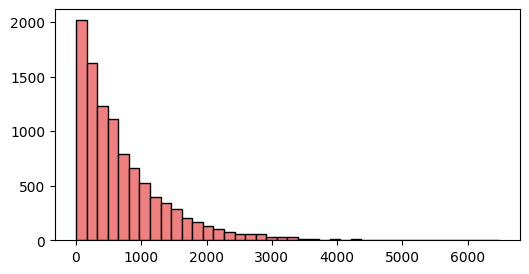

In [9]:
plt.figure(figsize=[6,3])
plt.hist(T, bins=40, color='lightcoral', edgecolor='k')
plt.show()

## Part 3.C
Suppose that the factory purchases a specialized insurance policy to offset the loss in sales due to an outage. Whenever there is an outage, the insurance policy will make a payment to the owners of the factory. The size of the payment is based on the length of the shutdown as shown below.

$$\textrm{Payment} = 50 \cdot T^{0.6}$$

Use the cell below to complete the following tasks.
1. Calculate the insurance payment for each observation of $T$ in the sample generated in Part 3.A.
2. Calculate and print the mean and standard deviation of the sample of payments.
  

In [10]:
payment = 50 * (T ** 0.6)
print(payout.mean())
print(payout.std(ddof=1))

12.102127980800965
23.312206437981445


## Part 3.D

Replace the blank in the cell below with the name of the variable representing the sample of payments and then run the cell.

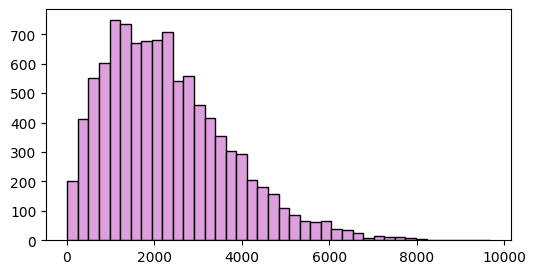

In [11]:
plt.figure(figsize=[6,3])
plt.hist(payment, bins=40, color='plum', edgecolor='k')
plt.show()

# Problem 4 - Memoryless Property

In this problem, we will explore the memoryless property of an exponential random variable.

Use the cell below to complete the following tasks:

1. Use NumPy to set a seed of 1.
2. Generate a sample of 100,000 observations of an exponential random variable defined by $X \sim EXP(\lambda = 1/50)$.
3. Use the sample to estimate each of the probabilities shown below. Print the resulting estimates rounded to 4 decimal places.

    * $P[X < 10]$
    * $P[X < 30 ~ |~ X > 20]$

    * $P[X < 60 ~ |~ X > 50]$

The memoryless property says that each of these probabilities should be equal. The true value of this probably is equal to 0.1813. The estimates generated should all be near this value.

In [12]:
np.random.seed(1)
X = np.random.exponential(scale=50, size=100_000)

P1_X = np.mean(X < 10)
P2_X = np.mean((X < 30) & (X > 20))
P3_X = np.mean((X < 60) & (X > 50))

print(round(P1_X, 4))
print(round(P2_X, 4))
print(round(P3_X, 4))

0.1822
0.1206
0.0668


# Problem 5 - Naive Bayes Classifier

In this problem, you will build a binary naive Bayes classifier. You will then apply the classifier to perform spam detection. The training data for this problem is stored in the arrays `X1` and `y1` that were imported near the beginning of this notebook.

The array `X1` is a 2D feature array with 10 features and 10,000 observations. Each observation is intended to represent a single email. Each feature is associated with a specific word that might be associated with a spam email. The features are binary (0/1) variables indicating the presence (1) or absence (0) of the word in the email.

The array `y1` contains the training labels. The target variable $Y$ is a binary variable indicating whether the email is spam (1) or not spam (0).

The shapes of these arrays are printed below.


In [13]:
print(X1.shape)
print(y1.shape)

(10000, 10)
(10000,)


## Part 5.A

Complete the definition of the function `naive_bayes()` in the cell below. The role of the three parameters are as follows:
* `X` is a 2D array containing the training features.
* `y` is a 1D array containing the training labels.
* `x` is a 1D array containing features for an observation to be classified.

The function should calculate a score for both classes (class 0 and class 1), and then calculate and return the likelihood ratio. These calculations are explained in the "Naive Bayes Classifier" lesson.

In [14]:
def naive_bayes(X, y, x):
    X_0 = X[y == 0, :]
    X_1 = X[y == 1, :]

    probs_0 = (X_0 == x).sum(axis=0) / len(X_0)
    probs_1 = (X_1 == x).sum(axis=0) / len(X_1)

    score_0 = np.mean(y == 0) * np.prod(probs_0)
    score_1 = np.mean(y == 1) * np.prod(probs_1)

    return score_1 / score_0

## Part 5.B

The cell below provides feature vectors for three emails. Apply the naive Bayes classifier to each of these emails and print the resulting likelihood ratios. Recall that any email with a likelihood ratio greater than 1 should be classified as spam.

In [15]:
email_1 = [0, 1, 0, 0, 1, 0, 0, 0, 1, 0]
email_2 = [1, 0, 1, 0, 0, 0, 0, 0, 0, 1]
email_3 = [0, 1, 0, 0, 0, 1, 0, 0, 1, 0]

LLR_1 = naive_bayes(X1, y1, email_1)
LLR_2 = naive_bayes(X1, y1, email_2)
LLR_3 = naive_bayes(X1, y1, email_3)

print(LLR_1)
print(LLR_2)
print(LLR_3)

5.321457423138157
0.09083662809060307
0.9548203449358919


# Data for Problems 6 - 8

In Problems 6 - 8, you will score, train, and apply logistic regression models. The training data for these problems is stored in the arrays `X2` and `y2` that were imported near the beginning of this notebook.

The array `X2` is a 2D feature array with 4 features and 1000 observations. The array `y2` contains the training labels. The shapes of these arrays are printed below.

In [16]:
print(X2.shape)
print(y2.shape)

(1000, 4)
(1000,)


# Problem 6 - Logistic Regression: Calculating NLL

In Problem 6, you will define three functions to be used to calculate the negative log-likelihood score for a proposed logistic regression model.


## Part 6.A

Use the cell below to create a function named `add_ones()`. The function should accept a single parameter `X` that is expected to be a 2D feature array. The function should append a column of ones to the front of the array and then return the new "extended" feature array. Guidance on how to accomplish this is provided in the lesson titled "Logistic Regression".

In [17]:
def add_ones(X):
    N = len(X)
    ones = np.ones(shape=(N,1))
    return np.hstack([ones, X])

You can test your `add_ones()` function by running the cell below. If all tests are passed, that does not necessarily guarantee that your function is correct, but it is likely correct.

In [18]:
unit_test_1(add_ones)

All tests passed.


## Part 6.B

Use the cell below to define a function named `predict_proba()`. The function should accept two parameters named `X` and `betas`. The parameter `X` is expected to be a 2D feature array and `betas` is excpected to be a 1D array of parameters defining a specific logistic regression model. The function should calculate and return the probability estimates $\hat p$ for the observations in `X`.

Guidance on how to accomplish this is provided in the lesson titled "Logistic Regression". Your `predict_proba()` function should make use of the `add_ones()` function to create the "extended" feature array.

In [19]:
def predict_proba(X, betas):
    XE = add_ones(X)
    z = np.dot(XE, betas)
    p_hat = 1 / (1 + np.exp(-z))
    return p_hat

You can test your `predict_proba()` function by running the cell below. If all tests are passed, that does not necessarily guarantee that your function is correct, but it is likely correct.

In [20]:
unit_test_2(predict_proba)

All tests passed.


## Part 6.C

Use the cell below the define a function named `calculate_NLL()`. The function should accept three parameters named `X`, `y`, and `betas`. The parameter `X` is expected to be a 2D feature array, `y` is expected to be a 1D label array, and `betas` is expected to be a 1D array of parameters defining a specific logistic regression model. The function should use `predict_proba()` to generate probability estimates for the observations contained in `X` and `y` and should then calculate and return the NLL score for the model given by `betas`. Guidance on how to accomplish this is provided in the lesson titled "Training a Logistic Regression Model".

In [21]:
def calculate_NLL(X, y, betas):
    p_hat = predict_proba(X, betas)
    pi = np.where(y == 1, p_hat, 1 - p_hat)
    NLL = -np.log(pi).sum()
    return NLL

You can test your `calculate_NLL()` function by running the cell below. If all tests are passed, that does not necessarily guarantee that your function is correct, but it is likely correct.

In [22]:
unit_test_3(calculate_NLL)

All tests passed.


## Part 6.D

You will now used your `calculate_NLL()` function to score two logistic regression models. The cell below contains definitions for two parameter arrays `betas1` and `betas2`. These arrays represent the two models shown below.

$$\hat p = \sigma \left( 2 - X^{(1)} - 3 X^{(2)} +2 X^{(3)} + 3 X^{(4)} \right)$$
$$\hat p = \sigma \left( 5 + X^{(1)} - 4 X^{(2)} + 3 X^{(3)} + 5 X^{(4)} \right)$$

Use your `calculate_NLL()` function to score each of these models using the training data stored in `X2` and `y2`. Print the NLL scores for both models, rounded to 2 decimal places.

In [23]:
betas1 = [2, -1, -3, 2, 3]
betas2 = [5, 1, -4, 3, 5]

NLL_1 = calculate_NLL(X2, y2, betas1)
NLL_2 = calculate_NLL(X2, y2, betas2)

print(round(NLL_1, 2))
print(round(NLL_2, 2))

450.23
118.16


# Problem 7 - Logistic Regression: Training the Model

In this problem, you will train a logistic regression model on `X2` and `y2`.




## Part 7.A

Use the cell below to define a function `train_logreg()`. The function should accept four parameters named `X`, `y`, `alpha`, and `n`. Descriptions of the parameters are as follows:
* `X` is expected to be a 2D feature array.
* `y` is expected to be a 1D label array.
* `alpha` is expected to be a learning rate.
* `steps` is the number of iterations of gradient descent to perform during training.

The function should apply gradient descent to determine optimal parameters for a logistic regression model. An outline of the steps that the function should perform is provided below.

1. The function `add_ones()` should be used to create an "extended" feature matrix `XE`.
2. A coeficient array named `betas` should be created with all values initialized to zero. The following code can be used for this task: `betas = np.zeros(XE.shape[1])`
3. A loop should be executed for a number of iterations indicated by `step`. Each iteration of the loop should perform the tasks below.

    a. Use `predict_proba()` to generate probability estimates.

    b. Use `calculate_NLL()` to calculate the NLL score for the current iteration of the model. Store this value in a variable named `NLL`.
    
    c. Calculate the gradient. The lesson titled "Training a Logistic Regression Model" explains how to do this.

    d. Use the gradient descent update rule to update the parameter estimates.

    e. Print an update message every 10 iterations. (Code for this has been provided).

4. When the loop is finished, return `betas`.

In [24]:
def train_logreg(X, y, alpha, steps):

    XE = add_ones(X)
    betas = np.zeros(XE.shape[1])

    for i in range(steps):

        p_hat = predict_proba(X, betas)
        NLL = calculate_NLL(X, y, betas)

        gradient = - np.matmul(y - p_hat, XE)
        betas = betas - alpha * gradient

        if (i+1) % 10 == 0:
            print(f'Iteration {i+1:003} - betas = {betas.round(3)}, NLL = {NLL:.2f}')

    return betas

## Part 7.B

Apply your `train_logreg()` function to the training data stored in `X2` and `y2`. Use `steps=300` and experiment with the learning rate. Your final `NLL` score should be 74.27 or less. Store the optimal parameters returned by the function in a variable.

In [25]:
optimal_betas = train_logreg(X2, y2, alpha = 0.01, steps=300)

Iteration 010 - betas = [ 2.628  0.388 -4.159  1.157  3.171], NLL = 90.73
Iteration 020 - betas = [ 3.358  0.116 -3.978  1.146  3.494], NLL = 80.28
Iteration 030 - betas = [ 3.695  0.062 -4.11   1.21   3.746], NLL = 78.12
Iteration 040 - betas = [ 3.93   0.033 -4.25   1.263  3.945], NLL = 76.89
Iteration 050 - betas = [ 4.113  0.01  -4.368  1.306  4.106], NLL = 76.11
Iteration 060 - betas = [ 4.262 -0.008 -4.466  1.34   4.238], NLL = 75.58
Iteration 070 - betas = [ 4.385 -0.024 -4.547  1.368  4.348], NLL = 75.23
Iteration 080 - betas = [ 4.488 -0.038 -4.615  1.391  4.441], NLL = 74.97
Iteration 090 - betas = [ 4.575 -0.049 -4.674  1.411  4.519], NLL = 74.79
Iteration 100 - betas = [ 4.649 -0.059 -4.724  1.428  4.586], NLL = 74.66
Iteration 110 - betas = [ 4.712 -0.067 -4.767  1.442  4.644], NLL = 74.56
Iteration 120 - betas = [ 4.767 -0.074 -4.804  1.454  4.693], NLL = 74.49
Iteration 130 - betas = [ 4.814 -0.081 -4.836  1.465  4.736], NLL = 74.44
Iteration 140 - betas = [ 4.855 -0.086

# Problem 8 - Logistic Regression: Applying the Model

The code cell below contains an array named `X_new`. This array represents a collection of new observations that the model should be applied to. Use the `predict_proba()` function to apply your optimal model to these observations. Print the resulting probability estimates rounded to 4 decimal places.


In [26]:
X_new = np.array([
    [ 4.1,  1.9,  0.4, 1.2],
    [ 1.6,  0.8, -3.6, 0.8],
    [-1.5,  1.7,  1.9, 0.2],
])

# Add code here
prob_X_new = predict_proba(X_new, optimal_betas)
print(prob_X_new.round(4))

[0.8408 0.3484 0.6543]


# Submission Instructions

1. Perform a Restart and Run All by clicking **Runtime > Restart session and run all**.
2. Copy the link to your notebook by clicking **Share > Copy Link**.
3. Paste the copied link into the `notebook_url` field in the [Notebook Renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool and then execute the cell to render the notebook.
4. The Notebook Renderer will open up a save file dialog. Save the resulting HTML file to your local machine.
5. Submit the HTML file to Canvas.
